<a href="https://colab.research.google.com/github/Saumya1295/Summer-Internship-Training/blob/main/Student_Marks_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install flask pyngrok joblib

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_marks_dataset_2000.csv to student_marks_dataset_2000 (3).csv


In [ ]:
df = pd.read_csv("student_marks_dataset_2000.csv")

df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Attendance_Percentage,Assignments_Submitted,Previous_Exam_Marks,Internet_Usage_Hours,Sleep_Hours,Extra_Curricular,Parent_Education_Level,Final_Marks
0,S000001,21,Male,3.1,81,16,30,4.8,7.7,No,High School,94.08
1,S000002,18,Female,3.0,60,9,90,10.2,7.6,Yes,Postgraduate,88.55
2,S000003,19,Female,10.9,76,1,16,6.0,3.2,No,Postgraduate,88.66
3,S000004,21,Female,3.0,66,5,54,8.1,3.0,No,Graduate,69.02
4,S000005,17,Female,3.3,94,7,92,4.7,3.6,No,Postgraduate,79.16


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              2000 non-null   object 
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   Study_Hours_Per_Day     2000 non-null   float64
 4   Attendance_Percentage   2000 non-null   int64  
 5   Assignments_Submitted   2000 non-null   int64  
 6   Previous_Exam_Marks     2000 non-null   int64  
 7   Internet_Usage_Hours    2000 non-null   float64
 8   Sleep_Hours             2000 non-null   float64
 9   Extra_Curricular        2000 non-null   object 
 10  Parent_Education_Level  2000 non-null   object 
 11  Final_Marks             2000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 187.6+ KB


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Assignments_Submitted,0
Previous_Exam_Marks,0
Internet_Usage_Hours,0
Sleep_Hours,0
Extra_Curricular,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
activity_encoder = LabelEncoder()
parent_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])

df["Extra_Curricular"] = activity_encoder.fit_transform(
    df["Extra_Curricular"]
)

df["Parent_Education_Level"] = parent_encoder.fit_transform(
    df["Parent_Education_Level"]
)

df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Attendance_Percentage,Assignments_Submitted,Previous_Exam_Marks,Internet_Usage_Hours,Sleep_Hours,Extra_Curricular,Parent_Education_Level,Final_Marks
0,S000001,21,1,3.1,81,16,30,4.8,7.7,0,2,94.08
1,S000002,18,0,3.0,60,9,90,10.2,7.6,1,3,88.55
2,S000003,19,0,10.9,76,1,16,6.0,3.2,0,3,88.66
3,S000004,21,0,3.0,66,5,54,8.1,3.0,0,1,69.02
4,S000005,17,0,3.3,94,7,92,4.7,3.6,0,3,79.16


In [ ]:
print(df.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day', 'Attendance_Percentage', 'Assignments_Submitted', 'Previous_Exam_Marks', 'Internet_Usage_Hours', 'Sleep_Hours', 'Extra_Curricular', 'Parent_Education_Level', 'Final_Marks']


In [ ]:
X = df.drop(
    ["Student_ID", "Final_Marks"],
    axis=1
)

y = df["Final_Marks"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 10)
(400, 10)


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


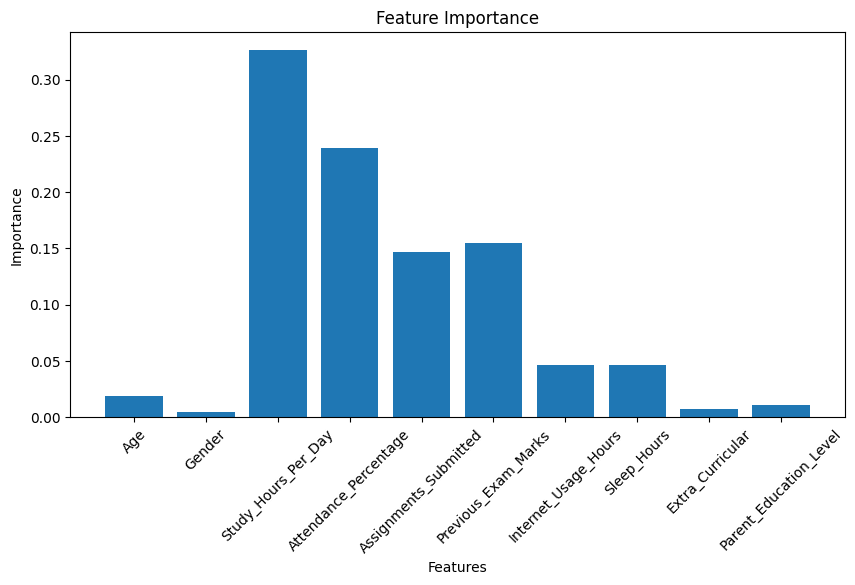

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": predictions.round(2)
})

comparison["Error"] = (
    comparison["Actual Marks"] -
    comparison["Predicted Marks"]
).round(2)

comparison["Performance"] = comparison["Predicted Marks"].apply(
    lambda x: "Excellent ⭐" if x >= 90
    else "Very Good 👍" if x >= 75
    else "Average 🙂" if x >= 60
    else "Needs Improvement 📚"
)

comparison.head(10)

,Actual Marks,Predicted Marks,Error,Performance
0,100.00,97.33,2.67,Excellent ⭐
1,75.41,83.44,-8.03,Very Good 👍
2,91.16,95.41,-4.25,Excellent ⭐
3,79.17,90.08,-10.91,Excellent ⭐
4,86.19,94.42,-8.23,Excellent ⭐
5,78.99,89.34,-10.35,Very Good 👍
6,80.10,74.63,5.47,Average 🙂
7,93.97,92.39,1.58,Excellent ⭐
8,97.25,91.26,5.99,Excellent ⭐
9,100.00,94.96,5.04,Excellent ⭐


In [ ]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, predictions)

print("Model Accuracy:", round(accuracy*100,2), "%")

Model Accuracy: 76.39 %


In [ ]:
print("MAE :", mean_absolute_error(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 Score:", r2_score(y_test, predictions))

MAE : 5.449631125000003
MSE : 43.861805503181294
RMSE: 6.622824586472247
R2 Score: 0.7638516824925381


In [ ]:
joblib.dump(model, "student_marks_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
os.makedirs("templates", exist_ok=True)

In [149]:
html_code = """
<!DOCTYPE html>
<html>
<head>
<title>Student Marks Prediction</title>
<style>

body{
    font-family:Arial;
    background: linear-gradient(to right,#74ebd5,#ACB6E5);
}

.container{
    width:600px;
    margin:auto;
    margin-top:40px;
    background:white;
    padding:30px;
    border-radius:20px;
    box-shadow:0px 0px 15px gray;
}

input,select{
    width:95%;
    padding:12px;
    margin:10px;
    border-radius:8px;
    border:1px solid gray;
}

button{
    padding:12px 20px;
    border:none;
    border-radius:8px;
    cursor:pointer;
    background:#4CAF50;
    color:white;
    font-size:16px;
}

button:hover{
    transform:scale(1.05);
}

</style>
</head>
<body style="background:off white;">

<div class="container">

<center>
<img src="https://img.icons8.com/color/96/student-male--v1.png">

<h1>Student Marks Prediction System</h1>

<p>
This machine learning system predicts final exam scores using
study habits, attendance, sleep schedule, previous marks and
other student information.
</p>
</center>

<form action="/predict" method="post">

<input name="Age" placeholder="Age">

<select name="Gender">
<option value="0">Male</option>
<option value="1">Female</option>
</select>

<input name="Study_Hours_Per_Day" placeholder="Study Hours Per Day">
<input name="Attendance_Percentage" placeholder="Attendance Percentage">
<input name="Assignments_Submitted" placeholder="Assignments Submitted">
<input name="Previous_Exam_Marks" placeholder="Previous Exam Marks">
<input name="Internet_Usage_Hours" placeholder="Internet Usage Hours">
<input name="Sleep_Hours" placeholder="Sleep Hours">
<select name="Extra_Curricular">
    <option value="0">No Extra Curricular Activities</option>
    <option value="1">Participates in Extra Curricular Activities</option>
    </select>
<select name="Parent_Education_Level">
    <option value="0">High School</option>
    <option value="1">Graduate</option>
    <option value="2">Post Graduate</option>
    <option value="3">Doctorate</option>
    </select>

<button type="submit">Predict Marks</button>

</form>

<div style="margin-top:20px;
background:#f5f5f5;
padding:20px;
border-radius:10px;">

<h2>{{prediction_text|safe}}</h2>

</div>
<hr>

<center>
<h3>Developed by Saumya Singh</h3>
<p>B.Tech CSE | Machine Learning Internship Project 2026</p>
</center>

</div>


</body>
</html>
"""

In [150]:
with open("templates/index.html", "w") as file:
    file.write(html_code)

In [151]:
backend_code = '''

from flask import Flask, render_template, request
import numpy as np
import joblib

app = Flask(__name__)

model = joblib.load("student_marks_model.pkl")

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():

    values = [
        float(request.form["Age"]),
        float(request.form["Gender"]),
        float(request.form["Study_Hours_Per_Day"]),
        float(request.form["Attendance_Percentage"]),
        float(request.form["Assignments_Submitted"]),
        float(request.form["Previous_Exam_Marks"]),
        float(request.form["Internet_Usage_Hours"]),
        float(request.form["Sleep_Hours"]),
        float(request.form["Extra_Curricular"]),
        float(request.form["Parent_Education_Level"])

    ]

    prediction = model.predict([values])[0]

    return render_template(
        "index.html",
        prediction_text=f"Predicted Final Exam Score: {prediction:.2f}"
    )

if __name__ == "__main__":
    app.run()
'''

with open("app.py", "w") as file:
    file.write(backend_code)

In [152]:
!pkill -f app.py

In [153]:
from threading import Thread
import os

def run_app():
  os.system("python app.py")

Thread(target=run_app).start()

In [154]:
!pkill ngrok

In [155]:
from pyngrok import ngrok
public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://antacid-unvented-constable.ngrok-free.dev" -> "http://localhost:5000"
